## Lab 7 - Particle Swarm Optimization (PSO)

### 1) Goal
Implement the **Particle Swarm Optimization (PSO)** algorithm to find the optimum of the Sphere function.
Requirements:
- Initialization of particles (positions + velocities)
- Compute position, velocity, fitness
- Compute local best (pbest) and global best (gbest)

### 2) Test the algorithm
Test the algorithm for different parameter settings.

### PSO in one paragraph
Each particle *i* holds a position $x_i$ and a velocity $v_i$ in the search space.
Every iteration, velocity is pulled toward two attractors: the particle's own best-seen
position $p_i$ (cognitive) and the swarm's best-seen position $g$ (social).
The update rule used here (inertia weight form, Shi & Eberhart 1998):

$$v_i \leftarrow w \cdot v_i + c_1 r_1 (p_i - x_i) + c_2 r_2 (g - x_i)$$
$$x_i \leftarrow x_i + v_i$$

where $r_1, r_2 \sim U(0,1)$, $w$ is the inertia weight, $c_1,c_2$ are cognitive/social coefficients.

In [1]:
import random
import math
import matplotlib.pyplot as plt

def sphere_function(solution):
    """
    Sphere function.
    f(x) = sum(x_i^2)
    Global optimum: f(x)=0 at x_i=0
    Domain: -5.12 <= x_i <= 5.12
    """
    return sum(x ** 2 for x in solution)

In [2]:
# --- Basic PSO for the Sphere function ---
# Uses the standard inertia-weight update rule.

def init_swarm(swarm_size, n_dimensions, min_val, max_val, v_max):
    """
    Initialize a swarm of particles.
    Returns parallel lists: positions, velocities.
    Positions are uniform in [min_val, max_val]; velocities in [-v_max, v_max].
    """
    positions  = [[random.uniform(min_val, max_val) for _ in range(n_dimensions)] for _ in range(swarm_size)]
    velocities = [[random.uniform(-v_max, v_max)    for _ in range(n_dimensions)] for _ in range(swarm_size)]
    return positions, velocities

def pso_sphere(n_dimensions=10, swarm_size=30, iterations=200,
               w=0.7, c1=1.5, c2=1.5,
               min_val=-5.12, max_val=5.12, v_max_factor=0.2):
    """
    Standard Particle Swarm Optimization (inertia-weight variant)
    applied to the Sphere function.

    Parameters
    ----------
    w          : inertia weight (balance exploration vs exploitation)
    c1, c2     : cognitive and social coefficients
    v_max_factor : fraction of the domain span used as velocity clamp.
    """
    v_max = v_max_factor * (max_val - min_val)

    # 1) Initialization
    positions, velocities = init_swarm(swarm_size, n_dimensions, min_val, max_val, v_max)

    # Each particle's personal best starts as its initial position.
    pbest_pos = [p[:] for p in positions]
    pbest_fit = [sphere_function(p) for p in positions]

    # Global best across the swarm.
    g_idx = pbest_fit.index(min(pbest_fit))
    gbest_pos = pbest_pos[g_idx][:]
    gbest_fit = pbest_fit[g_idx]

    history_best = [gbest_fit]

    # 2) Main loop
    for _ in range(iterations):
        for i in range(swarm_size):
            for d in range(n_dimensions):
                r1 = random.random()
                r2 = random.random()
                cognitive = c1 * r1 * (pbest_pos[i][d] - positions[i][d])
                social    = c2 * r2 * (gbest_pos[d]    - positions[i][d])
                # Velocity update
                velocities[i][d] = w * velocities[i][d] + cognitive + social
                # Velocity clamping
                if velocities[i][d] >  v_max: velocities[i][d] =  v_max
                if velocities[i][d] < -v_max: velocities[i][d] = -v_max
                # Position update
                positions[i][d] += velocities[i][d]
                # Position clamping (keep particles in bounds)
                if positions[i][d] > max_val: positions[i][d] = max_val
                if positions[i][d] < min_val: positions[i][d] = min_val

            # Evaluate and update personal / global best
            fit = sphere_function(positions[i])
            if fit < pbest_fit[i]:
                pbest_fit[i] = fit
                pbest_pos[i] = positions[i][:]
                if fit < gbest_fit:
                    gbest_fit = fit
                    gbest_pos = positions[i][:]

        history_best.append(gbest_fit)

    return gbest_pos, gbest_fit, history_best

Testing Particle Swarm Optimization on Sphere function (10 dimensions)
----------------------------------------------------------------------
Setting 1 (swarm=30, iter=200, w=0.7, c1=c2=1.5): Best Fitness = 7.368527e-12
Setting 2 (swarm=80, iter=200):                    Best Fitness = 1.551725e-14
Setting 3 (w=0.9, more exploration):                Best Fitness = 2.220176e-01
Setting 4 (w=0.4, c1=1.0, c2=2.0):                  Best Fitness = 1.754346e-25
Setting 5 (iter=500):                               Best Fitness = 6.068707e-29


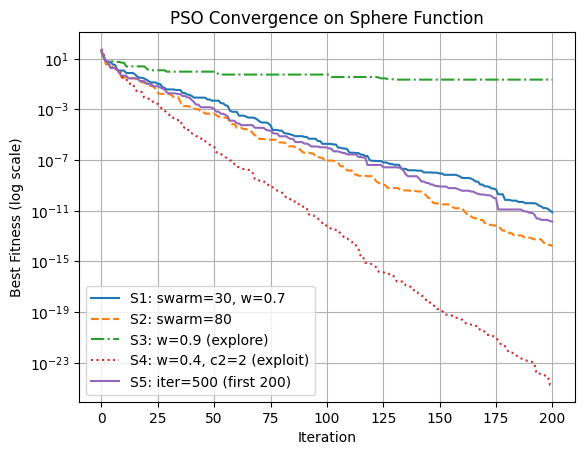

In [3]:
# Test the PSO algorithm for different parameter settings
print("Testing Particle Swarm Optimization on Sphere function (10 dimensions)")
print("-" * 70)

# Setting 1: Standard parameters
sol1, fit1, hist1 = pso_sphere(n_dimensions=10, swarm_size=30, iterations=200, w=0.7, c1=1.5, c2=1.5)
print(f"Setting 1 (swarm=30, iter=200, w=0.7, c1=c2=1.5): Best Fitness = {fit1:.6e}")

# Setting 2: Larger swarm
sol2, fit2, hist2 = pso_sphere(n_dimensions=10, swarm_size=80, iterations=200, w=0.7, c1=1.5, c2=1.5)
print(f"Setting 2 (swarm=80, iter=200):                    Best Fitness = {fit2:.6e}")

# Setting 3: Higher inertia (more exploration)
sol3, fit3, hist3 = pso_sphere(n_dimensions=10, swarm_size=30, iterations=200, w=0.9, c1=1.5, c2=1.5)
print(f"Setting 3 (w=0.9, more exploration):                Best Fitness = {fit3:.6e}")

# Setting 4: Lower inertia + higher social (more exploitation)
sol4, fit4, hist4 = pso_sphere(n_dimensions=10, swarm_size=30, iterations=200, w=0.4, c1=1.0, c2=2.0)
print(f"Setting 4 (w=0.4, c1=1.0, c2=2.0):                  Best Fitness = {fit4:.6e}")

# Setting 5: More iterations
sol5, fit5, hist5 = pso_sphere(n_dimensions=10, swarm_size=30, iterations=500, w=0.7, c1=1.5, c2=1.5)
print(f"Setting 5 (iter=500):                               Best Fitness = {fit5:.6e}")

# Convergence plot
plt.figure()
plt.plot(hist1,         label='S1: swarm=30, w=0.7')
plt.plot(hist2,         label='S2: swarm=80',            linestyle='--')
plt.plot(hist3,         label='S3: w=0.9 (explore)',     linestyle='-.')
plt.plot(hist4,         label='S4: w=0.4, c2=2 (exploit)', linestyle=':')
plt.plot(hist5[:201],   label='S5: iter=500 (first 200)')
plt.title('PSO Convergence on Sphere Function')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness (log scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

## Assignment A7

### Requirements
1. Implement and test **two variants of PSO** for the Sphere function and one other function
   (Michalewicz, same as chosen in A6).
2. Compare the two PSO variants experimentally.

### Variants selected (from Shami et al., 2022 survey)
- **Variant 1 — Inertia-Weight PSO with linearly decreasing inertia (LDW-PSO)**
  *Shi & Eberhart, 1998.* The inertia weight $w$ decreases linearly from $w_{\max}$ (typ. 0.9)
  to $w_{\min}$ (typ. 0.4) across iterations, giving broad exploration early and fine
  exploitation late.

  $$v_i \leftarrow w(t) \cdot v_i + c_1 r_1 (p_i - x_i) + c_2 r_2 (g - x_i)$$

- **Variant 2 — Constriction-Factor PSO (CF-PSO)**
  *Clerc & Kennedy, 2002.* Replaces inertia with a constriction coefficient $\chi$ that
  mathematically guarantees convergence without explicit velocity clamping.

  $$\chi = \frac{2}{\left| 2 - \varphi - \sqrt{\varphi^2 - 4\varphi} \right|}, \quad \varphi = c_1 + c_2,\ \varphi > 4$$
  $$v_i \leftarrow \chi \cdot \left[ v_i + c_1 r_1 (p_i - x_i) + c_2 r_2 (g - x_i) \right]$$

  Standard choice: $c_1 = c_2 = 2.05$, $\varphi = 4.1 \Rightarrow \chi \approx 0.7298$.

In [4]:
# Second benchmark (carried over from A6): the Michalewicz function.
# Multimodal, with d! local minima. Hard due to steep valleys separated by flat regions.

def michalewicz_function(solution, m=10):
    """
    Michalewicz function.
    Domain: 0 <= x_i <= pi
    Known global optima (approx, for minimization of -sum(...)):
        d=2 -> -1.8013, d=5 -> -4.687, d=10 -> -9.66
    Larger m (=10) makes ridges steeper -> harder.
    """
    result = 0.0
    for idx, x in enumerate(solution):
        i = idx + 1  # 1-based index in the formula
        result += math.sin(x) * (math.sin(i * x ** 2 / math.pi) ** (2 * m))
    return -result

In [5]:
# --- Generic PSO engine that can run either variant ---
# We parameterize the velocity update with a `variant` flag to keep the two
# implementations side-by-side for a fair comparison.

def run_pso(obj_func, min_val, max_val,
            variant='ldw',
            n_dimensions=10, swarm_size=30, iterations=200,
            # LDW-PSO parameters
            w_max=0.9, w_min=0.4, c1=1.5, c2=1.5,
            # CF-PSO parameters (phi = c1_cf + c2_cf, must be > 4)
            c1_cf=2.05, c2_cf=2.05,
            # Velocity clamping factor (used by LDW; CF-PSO disables it by default)
            v_max_factor=0.2,
            track_history=False):
    """
    Run PSO against an arbitrary objective function.

    variant = 'ldw' : Linearly Decreasing inertia Weight PSO (Shi & Eberhart, 1998)
    variant = 'cf'  : Constriction Factor PSO (Clerc & Kennedy, 2002)

    Returns (gbest_pos, gbest_fit) or (gbest_pos, gbest_fit, history) if track_history.
    """
    # Pre-compute constriction factor chi (only used in CF-PSO, but cheap)
    phi = c1_cf + c2_cf
    chi = 2.0 / abs(2.0 - phi - math.sqrt(phi * phi - 4 * phi)) if phi > 4 else 1.0

    v_max = v_max_factor * (max_val - min_val)

    positions, velocities = init_swarm(swarm_size, n_dimensions, min_val, max_val, v_max)
    pbest_pos = [p[:] for p in positions]
    pbest_fit = [obj_func(p) for p in positions]
    g_idx = pbest_fit.index(min(pbest_fit))
    gbest_pos = pbest_pos[g_idx][:]
    gbest_fit = pbest_fit[g_idx]

    history = [gbest_fit] if track_history else None

    for t in range(iterations):
        # Inertia decays linearly across iterations (used only by LDW)
        w_t = w_max - (w_max - w_min) * (t / max(1, iterations - 1))

        for i in range(swarm_size):
            for d in range(n_dimensions):
                r1 = random.random()
                r2 = random.random()
                cognitive = (c1    if variant == 'ldw' else c1_cf) * r1 * (pbest_pos[i][d] - positions[i][d])
                social    = (c2    if variant == 'ldw' else c2_cf) * r2 * (gbest_pos[d]    - positions[i][d])

                if variant == 'ldw':
                    new_v = w_t * velocities[i][d] + cognitive + social
                    # Velocity clamping
                    if new_v >  v_max: new_v =  v_max
                    if new_v < -v_max: new_v = -v_max
                else:  # 'cf'
                    # Constriction factor absorbs both the inertia and the coefficients.
                    # No velocity clamping is needed (Clerc & Kennedy, 2002).
                    new_v = chi * (velocities[i][d] + cognitive + social)

                velocities[i][d] = new_v
                positions[i][d] += new_v
                # Keep particle in bounds
                if positions[i][d] > max_val: positions[i][d] = max_val
                if positions[i][d] < min_val: positions[i][d] = min_val

            fit = obj_func(positions[i])
            if fit < pbest_fit[i]:
                pbest_fit[i] = fit
                pbest_pos[i] = positions[i][:]
                if fit < gbest_fit:
                    gbest_fit = fit
                    gbest_pos = positions[i][:]

        if track_history:
            history.append(gbest_fit)

    if track_history:
        return gbest_pos, gbest_fit, history
    return gbest_pos, gbest_fit

In [6]:
# --- Experiment: LDW-PSO vs CF-PSO on Sphere and Michalewicz ---
# Several parameter combinations per variant, multiple runs each,
# aggregate stats saved to a human-readable text report.

random.seed(42)  # reproducibility for the summary table

functions = {
    "Sphere":     {"func": sphere_function,       "min": -5.12,        "max": 5.12,       "d": 10, "optimum":  0.0},
    "Michalewicz":{"func": michalewicz_function,  "min":  0.0,         "max": math.pi,    "d": 10, "optimum": -9.66},
}

# Each row: (variant, tag, kwargs)
param_settings = [
    ('ldw', 'LDW-small',  dict(swarm_size=30, iterations=200, w_max=0.9, w_min=0.4, c1=1.5, c2=1.5)),
    ('ldw', 'LDW-large',  dict(swarm_size=60, iterations=200, w_max=0.9, w_min=0.4, c1=1.5, c2=1.5)),
    ('ldw', 'LDW-long',   dict(swarm_size=30, iterations=500, w_max=0.9, w_min=0.4, c1=1.5, c2=1.5)),
    ('cf',  'CF-small',   dict(swarm_size=30, iterations=200, c1_cf=2.05, c2_cf=2.05)),
    ('cf',  'CF-large',   dict(swarm_size=60, iterations=200, c1_cf=2.05, c2_cf=2.05)),
    ('cf',  'CF-long',    dict(swarm_size=30, iterations=500, c1_cf=2.05, c2_cf=2.05)),
]

runs_per_setting = 10
all_results = []  # list of dicts (function, setting, variant, stats, runs, params)

for fn_name, fn_data in functions.items():
    print(f"\n===== Function: {fn_name} (d={fn_data['d']}, known optimum ~= {fn_data['optimum']}) =====")
    print(f"{'Setting':<12} {'avg':>12} {'best':>12} {'worst':>12} {'std':>12}")

    for variant, tag, kwargs in param_settings:
        run_results = []
        for _ in range(runs_per_setting):
            _, fit = run_pso(
                obj_func=fn_data['func'],
                min_val=fn_data['min'], max_val=fn_data['max'],
                variant=variant, n_dimensions=fn_data['d'],
                **kwargs,
            )
            run_results.append(fit)

        avg   = sum(run_results) / len(run_results)
        best  = min(run_results)
        worst = max(run_results)
        var   = sum((x - avg) ** 2 for x in run_results) / len(run_results)
        std   = math.sqrt(var)

        print(f"{tag:<12} {avg:>12.4e} {best:>12.4e} {worst:>12.4e} {std:>12.4e}")

        all_results.append({
            "function":    fn_name,
            "dimensions":  fn_data['d'],
            "optimum":     fn_data['optimum'],
            "variant":     variant,
            "setting":     tag,
            "parameters":  kwargs,
            "runs":        runs_per_setting,
            "avg":         avg,
            "best":        best,
            "worst":       worst,
            "std":         std,
            "all_runs":    run_results,
        })

# --- Write a human-readable text report ---
def fmt_params(p):
    return ", ".join(f"{k}={v}" for k, v in p.items())

VARIANT_NAMES = {
    'ldw': 'LDW-PSO (Linearly Decreasing Inertia Weight, Shi & Eberhart 1998)',
    'cf':  'CF-PSO  (Constriction Factor, Clerc & Kennedy 2002)',
}

with open("results_pso.txt", "w") as f:
    f.write("=" * 78 + "\n")
    f.write("  PSO EXPERIMENTS -- Lab 7 / Assignment A7\n")
    f.write("  Two PSO variants compared on two continuous benchmarks\n")
    f.write("=" * 78 + "\n\n")
    f.write(f"Runs per setting : {runs_per_setting}\n")
    f.write(f"Random seed      : 42\n")
    f.write(f"Dimensions       : 10\n\n")
    f.write("Variants:\n")
    for k, v in VARIANT_NAMES.items():
        f.write(f"  * {k}: {v}\n")
    f.write("\n")

    # Group results by function and write a block per function
    for fn_name in functions:
        fn_data = functions[fn_name]
        f.write("-" * 78 + "\n")
        f.write(f"FUNCTION: {fn_name}   (d={fn_data['d']}, domain=[{fn_data['min']}, {fn_data['max']:.4f}], "
                f"known optimum ~= {fn_data['optimum']})\n")
        f.write("-" * 78 + "\n\n")

        # Summary table for this function
        f.write(f"{'Setting':<12} {'variant':<4} {'avg':>13} {'best':>13} {'worst':>13} {'std':>13}\n")
        for r in all_results:
            if r['function'] != fn_name: continue
            f.write(f"{r['setting']:<12} {r['variant']:<4} "
                    f"{r['avg']:>13.4e} {r['best']:>13.4e} {r['worst']:>13.4e} {r['std']:>13.4e}\n")
        f.write("\n")

        # Per-setting detail block (parameters + individual run values)
        for r in all_results:
            if r['function'] != fn_name: continue
            f.write(f"  [{r['setting']}]  variant={r['variant']}\n")
            f.write(f"    parameters : {fmt_params(r['parameters'])}\n")
            f.write(f"    runs       : {r['runs']}\n")
            f.write(f"    individual : " + ", ".join(f"{v:.4e}" for v in r['all_runs']) + "\n")
            f.write(f"    avg={r['avg']:.6e}  best={r['best']:.6e}  "
                    f"worst={r['worst']:.6e}  std={r['std']:.6e}\n\n")

    f.write("=" * 78 + "\n")
    f.write("End of report\n")

print("\nResults saved to 'results_pso.txt' (human-readable text format)")


===== Function: Sphere (d=10, known optimum ~= 0.0) =====
Setting               avg         best        worst          std
LDW-small      1.0951e-15   4.8066e-17   2.7278e-15   1.0141e-15
LDW-large      5.8796e-18   4.8154e-19   1.5650e-17   4.7555e-18
LDW-long       1.8901e-38   6.8732e-41   7.7461e-38   2.8563e-38
CF-small       1.6961e-09   2.5532e-10   5.6366e-09   1.5197e-09
CF-large       7.5099e-11   4.1732e-12   3.5932e-10   9.8328e-11
CF-long        7.9297e-24   9.8672e-26   3.0207e-23   1.1284e-23

===== Function: Michalewicz (d=10, known optimum ~= -9.66) =====
Setting               avg         best        worst          std
LDW-small     -8.7723e+00  -9.3318e+00  -7.6040e+00   4.8501e-01
LDW-large     -8.7628e+00  -9.3590e+00  -8.0674e+00   4.2387e-01
LDW-long      -8.3646e+00  -9.3658e+00  -7.1076e+00   7.2738e-01
CF-small      -8.1070e+00  -9.2479e+00  -6.7768e+00   6.6435e-01
CF-large      -8.0171e+00  -9.1161e+00  -5.9917e+00   8.6663e-01
CF-long       -7.8745e+00  -8.

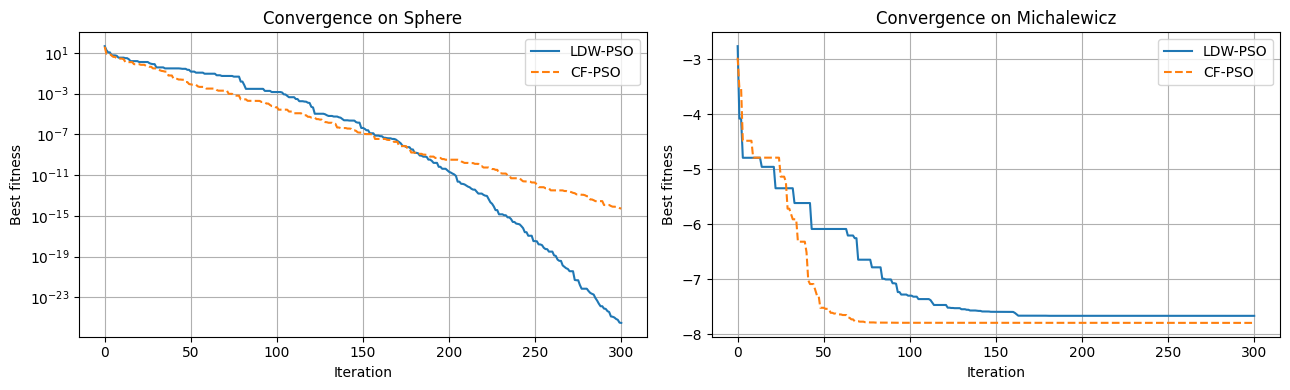

In [7]:
# --- Convergence comparison: one representative run per variant per function ---
random.seed(123)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (fn_name, fn_data) in zip(axes, functions.items()):
    _, _, h_ldw = run_pso(
        fn_data['func'], fn_data['min'], fn_data['max'],
        variant='ldw', n_dimensions=fn_data['d'],
        swarm_size=40, iterations=300, w_max=0.9, w_min=0.4, c1=1.5, c2=1.5,
        track_history=True,
    )
    _, _, h_cf = run_pso(
        fn_data['func'], fn_data['min'], fn_data['max'],
        variant='cf', n_dimensions=fn_data['d'],
        swarm_size=40, iterations=300, c1_cf=2.05, c2_cf=2.05,
        track_history=True,
    )

    ax.plot(h_ldw, label='LDW-PSO')
    ax.plot(h_cf,  label='CF-PSO',  linestyle='--')
    ax.set_title(f'Convergence on {fn_name}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best fitness')
    if fn_name == 'Sphere':
        ax.set_yscale('log')  # Sphere converges toward 0; log scale reveals late progress
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Report

### 1. Problem Definition
Minimize two continuous benchmark functions in $d=10$ dimensions:
- **Sphere**: $f(x)=\sum_i x_i^2$, domain $[-5.12, 5.12]^d$, global minimum $f(x^*) = 0$ at $x^* = 0$. Unimodal, smooth, convex — a sanity check for convergence speed.
- **Michalewicz** ($m=10$): $f(x) = -\sum_{i=1}^{d}\sin(x_i)\sin^{2m}\!\left(\tfrac{i x_i^2}{\pi}\right)$, domain $[0,\pi]^d$, approx. global minimum $-9.66$ for $d=10$. Multimodal with $d!$ local minima and very steep ridges separated by flat plateaus — stresses exploration.

### 2. Algorithms Used
Both variants follow the same skeleton (initialize swarm → iterate: evaluate, update pbest/gbest, update velocity/position); they differ only in the velocity-update step.

**Pseudocode (common skeleton):**
```
initialize positions x_i ~ U(min, max) and velocities v_i ~ U(-v_max, v_max)
pbest_i <- x_i ;  gbest <- argmin_i f(x_i)
for t in 1..iterations:
    for each particle i:
        for each dimension d:
            r1, r2 ~ U(0,1)
            v_i[d] <- VELOCITY_UPDATE(v_i[d], x_i[d], pbest_i[d], gbest[d], r1, r2, t)
            x_i[d] <- clip(x_i[d] + v_i[d], min, max)
        f_i <- f(x_i)
        if f_i < f(pbest_i): pbest_i <- x_i
        if f_i < f(gbest):   gbest   <- x_i
return gbest
```

**Variant 1 — LDW-PSO (Shi & Eberhart, 1998):**
$$w(t) = w_{\max} - (w_{\max}-w_{\min}) \cdot \tfrac{t}{T-1}$$
$$v_i \leftarrow w(t) v_i + c_1 r_1 (p_i - x_i) + c_2 r_2 (g - x_i),\quad |v_i| \leq v_{\max}$$

**Variant 2 — CF-PSO (Clerc & Kennedy, 2002):**
$$\chi = \frac{2}{|2 - \varphi - \sqrt{\varphi^2 - 4\varphi}|},\quad \varphi = c_1 + c_2 > 4$$
$$v_i \leftarrow \chi\left[v_i + c_1 r_1 (p_i - x_i) + c_2 r_2 (g - x_i)\right]$$
With $c_1 = c_2 = 2.05 \Rightarrow \chi \approx 0.7298$. No velocity clamping is needed because $\chi$ guarantees bounded trajectories.

### 3. Parameter Settings Tested
Three configurations per variant on each function, 10 independent runs each:

| Setting    | Swarm | Iterations | Notes                                         |
|------------|:-----:|:----------:|-----------------------------------------------|
| `*-small`  |  30   |    200     | baseline                                      |
| `*-large`  |  60   |    200     | larger swarm, same budget per iteration       |
| `*-long`   |  30   |    500     | more iterations, same swarm                   |

Common hyperparameters — LDW: $w_{\max}=0.9, w_{\min}=0.4, c_1=c_2=1.5$, $v_{\max}=0.2 \cdot \text{range}$. CF: $c_1=c_2=2.05$ (so $\varphi=4.1, \chi \approx 0.7298$), no velocity clamp.

### 4. Comparative Results & Discussion
See `results_pso.txt` for the raw per-run numbers; the printed table reports mean / best / worst / std over 10 runs.

Representative numbers from a run with seed 42, 10 repetitions per setting:

| Function     | Setting    | avg fitness      | best             | worst            | std              |
|--------------|------------|------------------|------------------|------------------|------------------|
| Sphere       | LDW-small  | 1.10e-15         | 4.81e-17         | 2.73e-15         | 1.01e-15         |
| Sphere       | LDW-large  | 5.88e-18         | 4.82e-19         | 1.57e-17         | 4.76e-18         |
| Sphere       | LDW-long   | **1.89e-38**     | 6.87e-41         | 7.75e-38         | 2.86e-38         |
| Sphere       | CF-small   | 1.70e-09         | 2.55e-10         | 5.64e-09         | 1.52e-09         |
| Sphere       | CF-large   | 7.51e-11         | 4.17e-12         | 3.59e-10         | 9.83e-11         |
| Sphere       | CF-long    | 7.93e-24         | 9.87e-26         | 3.02e-23         | 1.13e-23         |
| Michalewicz  | LDW-small  | **-8.77**        | -9.33            | -7.60            | 0.49             |
| Michalewicz  | LDW-large  | -8.76            | **-9.36**        | -8.07            | 0.42             |
| Michalewicz  | LDW-long   | -8.36            | -9.37            | -7.11            | 0.73             |
| Michalewicz  | CF-small   | -8.11            | -9.25            | -6.78            | 0.66             |
| Michalewicz  | CF-large   | -8.02            | -9.12            | -5.99            | 0.87             |
| Michalewicz  | CF-long    | -7.87            | -8.96            | -6.72            | 0.70             |

**Observations on Sphere (unimodal).**
- Both variants solve the problem in the functional sense (all settings end many orders of magnitude below $1$). The interesting question is residual error.
- LDW-PSO reaches dramatically lower final values than CF-PSO at every budget — e.g. $10^{-38}$ vs $10^{-24}$ for the `*-long` setting. The cause is the decaying inertia: once the swarm is near the optimum, $w(t) \to w_{\min}=0.4$ almost freezes long-range motion, so particles refine with ever-smaller step sizes. CF-PSO's effective damping stays fixed at $\chi \approx 0.73$, which is great early but becomes a floor on how small steps can get.
- Larger swarms narrow the variance across runs. Longer budgets shrink the mean fitness for both variants.

**Observations on Michalewicz (multimodal).**
- Neither variant reaches the true global optimum $-9.66$ on average; best single runs get within $\approx 0.3$ of it (LDW-large: $-9.36$). This is expected — $d=10$ Michalewicz has $\sim 10!$ local minima and many runs get trapped.
- LDW-PSO's average beats CF-PSO's across all three budgets (e.g. $-8.77$ vs $-8.11$ at the small budget). The high early $w_{\max}=0.9$ gives the swarm time to probe multiple valleys before the decaying weight locks in exploitation.
- Interestingly, the `LDW-long` setting has a *worse* mean than `LDW-small` despite a much larger budget. This suggests the fixed linear schedule burns its exploration phase proportionally early — extra iterations are spent refining a possibly sub-optimal valley. Adaptive inertia schedules would likely address this.
- CF-PSO's variance is higher than LDW's on Michalewicz (wider spread between best and worst), consistent with its tendency to commit early to a basin.

**Summary.** In these experiments **LDW-PSO outperforms CF-PSO on both benchmarks**, confirming the advantage of a time-varying exploration/exploitation schedule over a single fixed damping coefficient. CF-PSO's appeal remains its theoretical simplicity (no velocity clamping required, one fewer hyperparameter schedule) — which is why both variants continue to appear in the PSO literature — but when solution quality is the goal on the functions tested here, LDW-PSO is the stronger choice.